In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/models/shravankumarpandey/mnist-cnn-classifier/keras/v1.0/1/mnist_cnn_model.keras


# MNIST Handwritten Digit Classification using CNN

This notebook demonstrates a Convolutional Neural Network (CNN) trained on the MNIST dataset for handwritten digit recognition. The model achieves over 99% test accuracy and can classify digits from 0 to 9.

# Loading Libraries

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

2026-05-30 10:12:49.030650: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780135969.278064      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780135969.343339      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780135969.902941      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780135969.903016      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780135969.903020      58 computation_placer.cc:177] computation placer alr

# Loading Dataset

In [3]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print(X_train.shape)
print(X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28)
(10000, 28, 28)


# Visual Sample

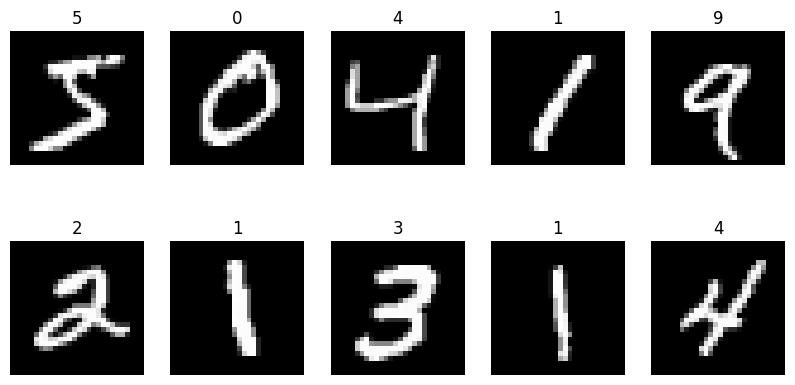

In [4]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(y_train[i])
    plt.axis('off')

plt.show()

# Load Publish Model

In [5]:
from tensorflow.keras.models import load_model

model = load_model("/kaggle/input/models/shravankumarpandey/mnist-cnn-classifier/keras/v1.0/1/mnist_cnn_model.keras")

I0000 00:00:1780135985.643090      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780135985.649067      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


# Evaluate Model

In [6]:
X_test = X_test.astype("float32") / 255.0
X_test = X_test.reshape(-1,28,28,1)

test_loss, test_acc = model.evaluate(X_test, tf.keras.utils.to_categorical(y_test,10))

print("Test Accuracy:", test_acc)

I0000 00:00:1780135987.947229     127 service.cc:152] XLA service 0x7e4bdc005730 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780135987.947279     127 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780135987.947286     127 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780135988.147211     127 cuda_dnn.cc:529] Loaded cuDNN version 91002


 62/313 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9913 - loss: 0.0234  

I0000 00:00:1780135989.781999     127 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9924 - loss: 0.0274
Test Accuracy: 0.9923999905586243


# Predict Sample Digits

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 641ms/step


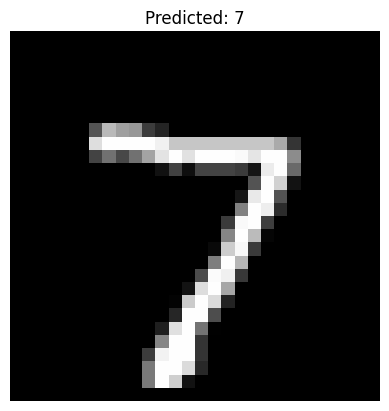

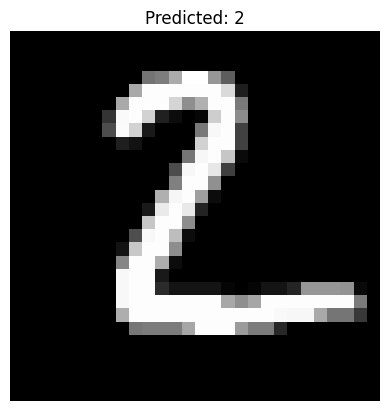

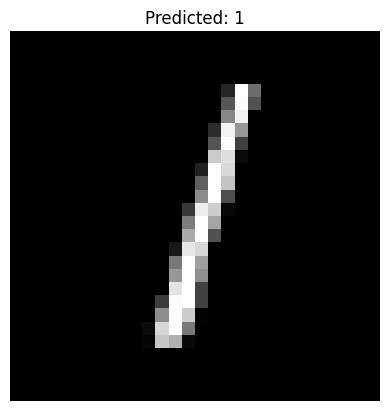

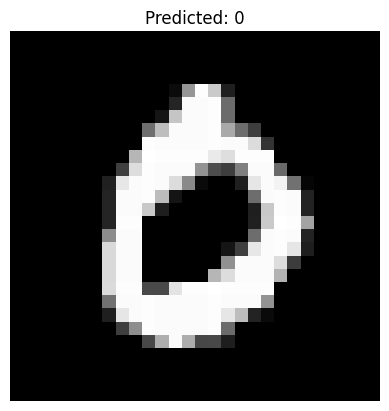

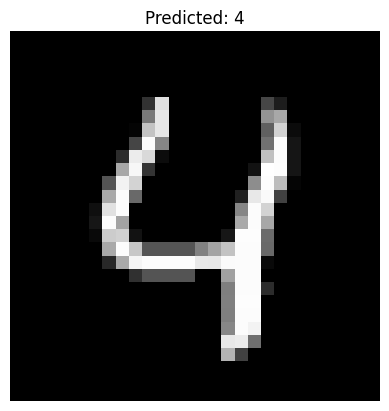

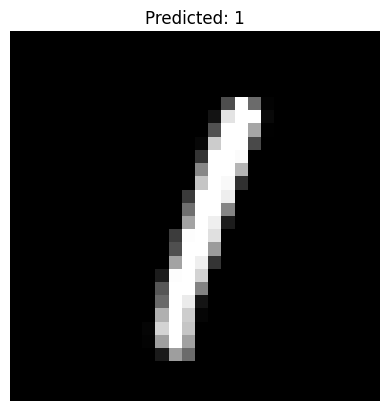

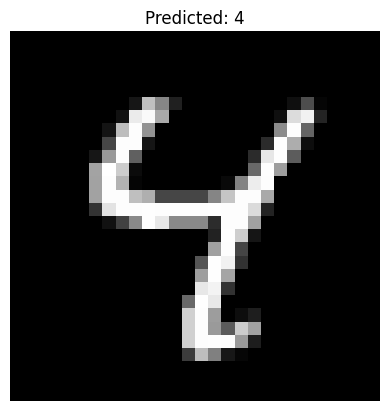

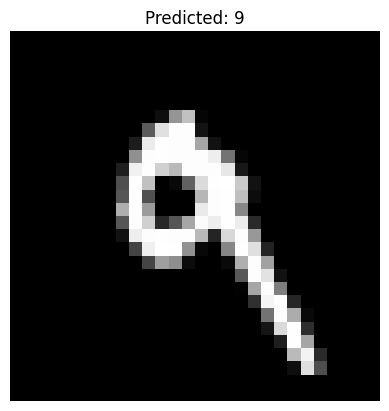

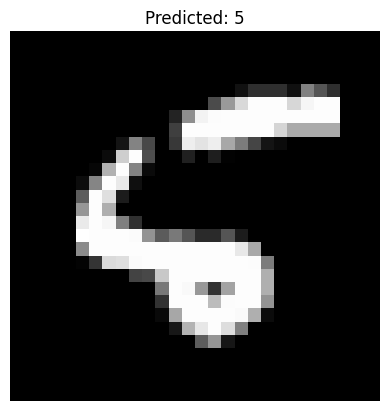

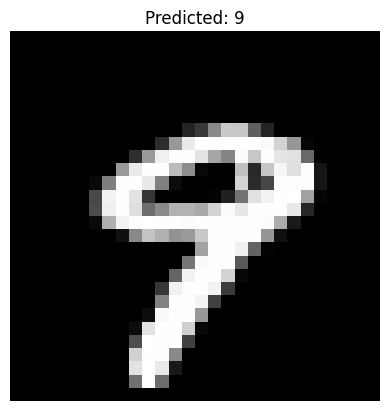

In [7]:
predictions = model.predict(X_test[:10])

for i in range(10):
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    plt.title(f"Predicted: {np.argmax(predictions[i])}")
    plt.axis('off')
    plt.show()

# Conclusion
## Results

- CNN-based digit classifier
- Trained on MNIST dataset
- Achieves 99%+ accuracy
- Ready for deployment and inference